# Считывание Данных

In [2]:
import pandas as pd 
import polars as pl
from datetime import datetime
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
drive_files = '/kaggle/input/datasets/shuhengmo/uber-nyc-forhire-vehicles-trip-data-2021/*.parquet'
drives_needed_cols = ["request_datetime", "PULocationID"]
drives = pl.scan_parquet(drive_files).select([pl.col(x) for x in drives_needed_cols])
print(drives.head(5).collect())

shape: (5, 2)
┌─────────────────────┬──────────────┐
│ request_datetime    ┆ PULocationID │
│ ---                 ┆ ---          │
│ datetime[ns]        ┆ i64          │
╞═════════════════════╪══════════════╡
│ 2021-01-01 00:28:09 ┆ 230          │
│ 2021-01-01 00:45:56 ┆ 152          │
│ 2021-01-01 00:21:15 ┆ 233          │
│ 2021-01-01 00:39:12 ┆ 142          │
│ 2021-01-01 00:46:11 ┆ 143          │
└─────────────────────┴──────────────┘


In [4]:
meteodata_files = '/kaggle/input/datasets/shuhengmo/uber-nyc-forhire-vehicles-trip-data-2021/nyc 2021-01-01 to 2021-12-31.csv'
meteo_needed_cols = [
    'datetime', 'temp', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
    'preciptype', 'snow', 'snowdepth', 'windgust','windspeed', 'winddir',
    'sealevelpressure', 'cloudcover', 'visibility', 'uvindex'
]
meteodata = pl.scan_csv(meteodata_files).select([pl.col(x) for x in meteo_needed_cols])
print(meteodata.head(5).collect())

shape: (5, 17)
┌────────────┬──────┬───────────┬──────┬───┬──────────────────┬────────────┬────────────┬─────────┐
│ datetime   ┆ temp ┆ feelslike ┆ dew  ┆ … ┆ sealevelpressure ┆ cloudcover ┆ visibility ┆ uvindex │
│ ---        ┆ ---  ┆ ---       ┆ ---  ┆   ┆ ---              ┆ ---        ┆ ---        ┆ ---     │
│ str        ┆ f64  ┆ f64       ┆ f64  ┆   ┆ f64              ┆ f64        ┆ f64        ┆ i64     │
╞════════════╪══════╪═══════════╪══════╪═══╪══════════════════╪════════════╪════════════╪═════════╡
│ 2021-01-01 ┆ 2.5  ┆ -0.2      ┆ -3.0 ┆ … ┆ 1028.9           ┆ 50.6       ┆ 14.0       ┆ 3       │
│ 2021-01-02 ┆ 5.8  ┆ 3.6       ┆ 1.2  ┆ … ┆ 1012.4           ┆ 63.9       ┆ 12.2       ┆ 5       │
│ 2021-01-03 ┆ 2.5  ┆ -1.6      ┆ -0.5 ┆ … ┆ 1017.0           ┆ 81.5       ┆ 13.2       ┆ 1       │
│ 2021-01-04 ┆ 3.6  ┆ 1.1       ┆ -0.2 ┆ … ┆ 1014.6           ┆ 89.3       ┆ 15.6       ┆ 4       │
│ 2021-01-05 ┆ 3.8  ┆ 1.3       ┆ -1.5 ┆ … ┆ 1013.1           ┆ 98.8       ┆ 16.0    

# Первичная обработка данных

## Сжимаем датасет до часовой точности, суммируя поездки по локациям

In [5]:
start_date = datetime(2021, 1, 1)
second_week = datetime(2021, 1, 7)

drives_lazy = (
    drives
    .filter(pl.col("request_datetime") >= start_date)
    # 1. Сначала агрегируем только по ключевым полям
    .group_by([
        pl.col("request_datetime").dt.truncate("1h").alias("hour_bucket"),
        "PULocationID"
    ])
    .agg(pl.len().alias("trips_count"))
    
    # 2. Сортируем сжатый датасет
    .sort(["PULocationID", "hour_bucket"])
)

print(drives_lazy.collect(engine="streaming").head(5))

shape: (5, 3)
┌─────────────────────┬──────────────┬─────────────┐
│ hour_bucket         ┆ PULocationID ┆ trips_count │
│ ---                 ┆ ---          ┆ ---         │
│ datetime[ns]        ┆ i64          ┆ u32         │
╞═════════════════════╪══════════════╪═════════════╡
│ 2021-01-01 05:00:00 ┆ 1            ┆ 1           │
│ 2021-01-01 07:00:00 ┆ 1            ┆ 1           │
│ 2021-01-01 10:00:00 ┆ 1            ┆ 1           │
│ 2021-01-01 12:00:00 ┆ 1            ┆ 1           │
│ 2021-01-01 16:00:00 ┆ 1            ┆ 1           │
└─────────────────────┴──────────────┴─────────────┘


## Заполняем временной ряд полностью, добавляя записи даже в которые не произошло ни одной поездки

In [6]:
end_date = drives_lazy.select(pl.col("hour_bucket").max()).collect().item()
target_dtype = drives_lazy.collect_schema()["hour_bucket"] # Получаем тип данных (например, Datetime('us'))
time_grid = pl.datetime_range(
    start=start_date, 
    end=end_date, 
    interval="1h", 
    eager=True
).alias("hour_bucket").to_frame().cast({"hour_bucket": target_dtype}).lazy()

locations = drives.select(pl.col("PULocationID").unique())

grid = time_grid.join(locations, how="cross")

full_drives_lazy = grid.join(
    drives_lazy, 
    on=["hour_bucket", "PULocationID"], 
    how="left"
).with_columns(
    pl.col("trips_count").fill_null(0) # Теперь дырок во времени нет
)

full_drives_lazy = full_drives_lazy.sort(["PULocationID", "hour_bucket"])

print(full_drives_lazy.collect(engine="streaming").head(6))

shape: (6, 3)
┌─────────────────────┬──────────────┬─────────────┐
│ hour_bucket         ┆ PULocationID ┆ trips_count │
│ ---                 ┆ ---          ┆ ---         │
│ datetime[ns]        ┆ i64          ┆ u32         │
╞═════════════════════╪══════════════╪═════════════╡
│ 2021-01-01 00:00:00 ┆ 1            ┆ 0           │
│ 2021-01-01 01:00:00 ┆ 1            ┆ 0           │
│ 2021-01-01 02:00:00 ┆ 1            ┆ 0           │
│ 2021-01-01 03:00:00 ┆ 1            ┆ 0           │
│ 2021-01-01 04:00:00 ┆ 1            ┆ 0           │
│ 2021-01-01 05:00:00 ┆ 1            ┆ 1           │
└─────────────────────┴──────────────┴─────────────┘


## Разделение request_datetime на hour, dayofweek, month, day

In [7]:
full_drives_lazy = (
    full_drives_lazy
    # 1. Достаем признаки времени из компактного hour_bucket
    .with_columns([
        pl.col("hour_bucket").dt.month().alias("month"),
        pl.col("hour_bucket").dt.day().alias("day"),
        pl.col("hour_bucket").dt.weekday().alias("dayofweek"),
        pl.col("hour_bucket").dt.hour().alias("hour"),
        pl.col("hour_bucket").dt.date().alias("date"),
    ])
    
    # 2. Считаем лаги на агрегированных данных
    .with_columns([
        pl.col("trips_count").shift(1).over("PULocationID").fill_null(0).alias("trips_lag_1h"),
        pl.col("trips_count").shift(24).over("PULocationID").fill_null(0).alias("trips_lag_day"),
        pl.col("trips_count").shift(24 * 7).over("PULocationID").fill_null(0).alias("trips_lag_week"),
    ])
    
    # 3. Отсекаем ненужный хвост (теперь это быстро)
    .filter(pl.col("hour_bucket") >= second_week)   
)

print(full_drives_lazy.head(5).collect())

shape: (5, 11)
┌────────────┬────────────┬────────────┬───────┬───┬───────────┬───────────┬───────────┬───────────┐
│ hour_bucke ┆ PULocation ┆ trips_coun ┆ month ┆ … ┆ date      ┆ trips_lag ┆ trips_lag ┆ trips_lag │
│ t          ┆ ID         ┆ t          ┆ ---   ┆   ┆ ---       ┆ _1h       ┆ _day      ┆ _week     │
│ ---        ┆ ---        ┆ ---        ┆ i8    ┆   ┆ date      ┆ ---       ┆ ---       ┆ ---       │
│ datetime[n ┆ i64        ┆ u32        ┆       ┆   ┆           ┆ u32       ┆ u32       ┆ u32       │
│ s]         ┆            ┆            ┆       ┆   ┆           ┆           ┆           ┆           │
╞════════════╪════════════╪════════════╪═══════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 2021-01-07 ┆ 1          ┆ 0          ┆ 1     ┆ … ┆ 2021-01-0 ┆ 1         ┆ 0         ┆ 0         │
│ 00:00:00   ┆            ┆            ┆       ┆   ┆ 7         ┆           ┆           ┆           │
│ 2021-01-07 ┆ 1          ┆ 1          ┆ 1     ┆ … ┆ 2021-01-0 ┆ 0         ┆

## Преобразование временных данных в метеоданных

In [8]:
meteodata_lazy = (
    meteodata.with_columns(
        pl.col('datetime').str.to_date().alias('date')
    )
    .drop('datetime')
)

print(meteodata_lazy.head(5).collect())

shape: (5, 17)
┌──────┬───────────┬──────┬──────────┬───┬────────────┬────────────┬─────────┬────────────┐
│ temp ┆ feelslike ┆ dew  ┆ humidity ┆ … ┆ cloudcover ┆ visibility ┆ uvindex ┆ date       │
│ ---  ┆ ---       ┆ ---  ┆ ---      ┆   ┆ ---        ┆ ---        ┆ ---     ┆ ---        │
│ f64  ┆ f64       ┆ f64  ┆ f64      ┆   ┆ f64        ┆ f64        ┆ i64     ┆ date       │
╞══════╪═══════════╪══════╪══════════╪═══╪════════════╪════════════╪═════════╪════════════╡
│ 2.5  ┆ -0.2      ┆ -3.0 ┆ 67.8     ┆ … ┆ 50.6       ┆ 14.0       ┆ 3       ┆ 2021-01-01 │
│ 5.8  ┆ 3.6       ┆ 1.2  ┆ 74.0     ┆ … ┆ 63.9       ┆ 12.2       ┆ 5       ┆ 2021-01-02 │
│ 2.5  ┆ -1.6      ┆ -0.5 ┆ 80.7     ┆ … ┆ 81.5       ┆ 13.2       ┆ 1       ┆ 2021-01-03 │
│ 3.6  ┆ 1.1       ┆ -0.2 ┆ 76.6     ┆ … ┆ 89.3       ┆ 15.6       ┆ 4       ┆ 2021-01-04 │
│ 3.8  ┆ 1.3       ┆ -1.5 ┆ 68.7     ┆ … ┆ 98.8       ┆ 16.0       ┆ 2       ┆ 2021-01-05 │
└──────┴───────────┴──────┴──────────┴───┴────────────┴──────────

## Join метеоданных 

In [9]:
result_lazy = full_drives_lazy.join(meteodata_lazy, on="date", how="inner")
result_lazy = result_lazy.drop("date")
result_df = result_lazy.collect()
result_df.head(25)

hour_bucket,PULocationID,trips_count,month,day,dayofweek,hour,trips_lag_1h,trips_lag_day,trips_lag_week,temp,feelslike,dew,humidity,precip,precipprob,preciptype,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,uvindex
datetime[ns],i64,u32,i8,i8,i8,i8,u32,u32,u32,f64,f64,f64,f64,f64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,i64
2021-01-07 00:00:00,1,0,1,7,4,0,1,0,0,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5
2021-01-07 01:00:00,1,1,1,7,4,1,0,0,0,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5
2021-01-07 02:00:00,1,0,1,7,4,2,1,0,0,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5
2021-01-07 03:00:00,1,0,1,7,4,3,0,0,0,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5
2021-01-07 04:00:00,1,0,1,7,4,4,0,0,0,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2021-01-07 20:00:00,1,1,1,7,4,20,1,0,0,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5
2021-01-07 21:00:00,1,1,1,7,4,21,1,0,0,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5
2021-01-07 22:00:00,1,2,1,7,4,22,1,1,0,1.9,-2.1,-6.4,54.9,0.0,0,null,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5


## Заполнение пропусков и кодирование типа осадков

In [10]:
result_df = (
    result_df.
    with_columns([
        pl.col("preciptype").str.contains("rain").fill_null(False).cast(pl.Int8).alias("is_rain"),
        pl.col("preciptype").str.contains("snow").fill_null(False).cast(pl.Int8).alias("is_snow")
    ])
    .drop("preciptype")
)
result_df.head(25)

hour_bucket,PULocationID,trips_count,month,day,dayofweek,hour,trips_lag_1h,trips_lag_day,trips_lag_week,temp,feelslike,dew,humidity,precip,precipprob,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,uvindex,is_rain,is_snow
datetime[ns],i64,u32,i8,i8,i8,i8,u32,u32,u32,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i8,i8
2021-01-07 00:00:00,1,0,1,7,4,0,1,0,0,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0,0
2021-01-07 01:00:00,1,1,1,7,4,1,0,0,0,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0,0
2021-01-07 02:00:00,1,0,1,7,4,2,1,0,0,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0,0
2021-01-07 03:00:00,1,0,1,7,4,3,0,0,0,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0,0
2021-01-07 04:00:00,1,0,1,7,4,4,0,0,0,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2021-01-07 20:00:00,1,1,1,7,4,20,1,0,0,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0,0
2021-01-07 21:00:00,1,1,1,7,4,21,1,0,0,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0,0
2021-01-07 22:00:00,1,2,1,7,4,22,1,1,0,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0,0


## Аналитика

In [11]:
cols_for_base_analysis = [
    "feelslike", "dew", "humidity",
    "snowdepth", "winddir", "sealevelpressure",
    "cloudcover", "visibility", "uvindex"
]

base_atributes = ["temp", "precip", "precipprob", "windgust", "windspeed"]

target = "trips_count"


description = {
    "hour_bucket": "Дата и время с точностью до часа",
    "PULocationID": "Зона такси TLC, в которой начался рейс",
    "trips_count": "Кол-во поездок за час из определенной зоны",
    "trips_lag_1h": "Кол-во поездок за час из определенной зоны за час до текущего времени",
    "trips_lag_day": "Кол-во поездок за сутки из определенной зоны за час до текущего времени",
    "trips_lag_week": "Кол-во поездок за неделю из определенной зоны за час до текущего времени",
    "hour": "Час вызова такси",
    "dayofweek": "День недели вызова такси(1-7)",
    "month": "Месяц вызова такси",
    "day": "День вызова такси",
    "temp": "Температура воздуха",
    "feelslike": "Ощущаемая температура воздуха",
    "dew": "Точка росы",
    "humidity": "Влажность",
    "precip": "Осадки?",
    "precipprob": "Вероятность осадков",
    "snowdepth": "Глубина снега",
    "windgust": "Порывы ветра",
    "windspeed": "Скорость ветра",
    "winddir": "Направление ветра",
    "sealevelpressure": "Атмосферное давление, приведенное к среднему уровню моря ",
    "cloudcover": "Облачность",
    "visibility": "Видимость",
    "uvindex": "УФ-Индекс"
}

## Анализ выбросов. Скользящее окно

In [12]:
window_size = 24 # Размер окна (например, 5 дней)
threshold = 3    # Коэффициент чувствительности
df_processed = result_df.with_columns([
    # 1. Считаем границы во Float64 (это неизбежно для математики)
    (pl.col(target).cast(pl.Float64).rolling_median(window_size=window_size, center=True)).alias("med"),
    (pl.col(target).cast(pl.Float64).rolling_std(window_size=window_size, center=True)).alias("std")
]).with_columns([
    # 2. Ограничиваем нижнюю границу нулем, чтобы она была логичной (поездки >= 0)
    (pl.col("med") + threshold * pl.col("std")).alias("upper"),
    (pl.col("med") - threshold * pl.col("std")).clip(lower_bound=0).alias("lower") 
]).with_columns([
    # 3. Срезаем выбросы и возвращаем в целое число (u32)
    pl.col(target).cast(pl.Float64)
      .clip(pl.col("lower"), pl.col("upper"))
      .round(0) # Округляем до ближайшего целого
      .cast(pl.UInt32) # Возвращаем в натуральный вид
      .alias("value_cleaned")
])

result_df = (
    df_processed.
    drop(["med", "std", "upper", "lower", "value_cleaned"])
)
result_df.head(43)

hour_bucket,PULocationID,trips_count,month,day,dayofweek,hour,trips_lag_1h,trips_lag_day,trips_lag_week,temp,feelslike,dew,humidity,precip,precipprob,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,uvindex,is_rain,is_snow
datetime[ns],i64,u32,i8,i8,i8,i8,u32,u32,u32,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i8,i8
2021-01-07 00:00:00,1,0,1,7,4,0,1,0,0,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0,0
2021-01-07 01:00:00,1,1,1,7,4,1,0,0,0,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0,0
2021-01-07 02:00:00,1,0,1,7,4,2,1,0,0,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0,0
2021-01-07 03:00:00,1,0,1,7,4,3,0,0,0,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0,0
2021-01-07 04:00:00,1,0,1,7,4,4,0,0,0,1.9,-2.1,-6.4,54.9,0.0,0,0.0,0.0,40.7,22.8,322.7,1018.5,7.6,16.0,5,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2021-01-08 14:00:00,1,0,1,8,5,14,0,2,0,0.2,-3.7,-6.9,59.2,0.0,0,0.0,0.0,43.5,20.5,242.7,1015.3,25.7,16.0,3,0,0
2021-01-08 15:00:00,1,1,1,8,5,15,0,0,0,0.2,-3.7,-6.9,59.2,0.0,0,0.0,0.0,43.5,20.5,242.7,1015.3,25.7,16.0,3,0,0
2021-01-08 16:00:00,1,1,1,8,5,16,1,2,1,0.2,-3.7,-6.9,59.2,0.0,0,0.0,0.0,43.5,20.5,242.7,1015.3,25.7,16.0,3,0,0


In [13]:
stats = []

for col in cols_for_base_analysis:
    stats.extend([
        pl.col(col).min().alias(f'{col}_min'),
        pl.col(col).max().alias(f'{col}_max'),
        pl.col(col).mean().alias(f'{col}_mean'),
        pl.col(col).median().alias(f'{col}_median'),
        pl.col(col).std().alias(f'{col}_std')
    ])

results = result_df.select(stats)
for col in cols_for_base_analysis:
    print(f"--- {col} ---")
    print(f"Описание: {description[col]}")
    print(f"Мин: {results[0, f'{col}_min']}")
    print(f"Макс: {results[0, f'{col}_max']}")
    print(f"Среднее: {results[0, f'{col}_mean']:.2f}")
    print(f"Медиана: {results[0, f'{col}_median']}")
    print(f"Ст. отк.: {results[0, f'{col}_std']:.2f}\n")

--- feelslike ---
Описание: Ощущаемая температура воздуха
Мин: -14.1
Макс: 33.6
Среднее: 13.31
Медиана: 14.5
Ст. отк.: 10.74

--- dew ---
Описание: Точка росы
Мин: -19.7
Макс: 22.3
Среднее: 5.89
Медиана: 6.1
Ст. отк.: 10.48

--- humidity ---
Описание: Влажность
Мин: 22.6
Макс: 93.0
Среднее: 60.05
Медиана: 60.7
Ст. отк.: 15.46

--- snowdepth ---
Описание: Глубина снега
Мин: 0.0
Макс: 31.7
Среднее: 1.67
Медиана: 0.0
Ст. отк.: 5.28

--- winddir ---
Описание: Направление ветра
Мин: 27.6
Макс: 322.7
Среднее: 198.87
Медиана: 216.8
Ст. отк.: 81.12

--- sealevelpressure ---
Описание: Атмосферное давление, приведенное к среднему уровню моря 
Мин: 996.9
Макс: 1034.1
Среднее: 1016.48
Медиана: 1016.2
Ст. отк.: 6.73

--- cloudcover ---
Описание: Облачность
Мин: 1.5
Макс: 100.0
Среднее: 53.30
Медиана: 52.8
Ст. отк.: 27.92

--- visibility ---
Описание: Видимость
Мин: 1.2
Макс: 16.0
Среднее: 14.81
Медиана: 16.0
Ст. отк.: 2.10

--- uvindex ---
Описание: УФ-Индекс
Мин: 0
Макс: 10
Среднее: 6.08
Медиана: 

## Распределение основных признаков

--- temp ---
Описание: Температура воздуха
Мин: -6.2
Макс: 31.2
Среднее: 14.25
Медиана: 14.5
Ст. отк.: 9.15



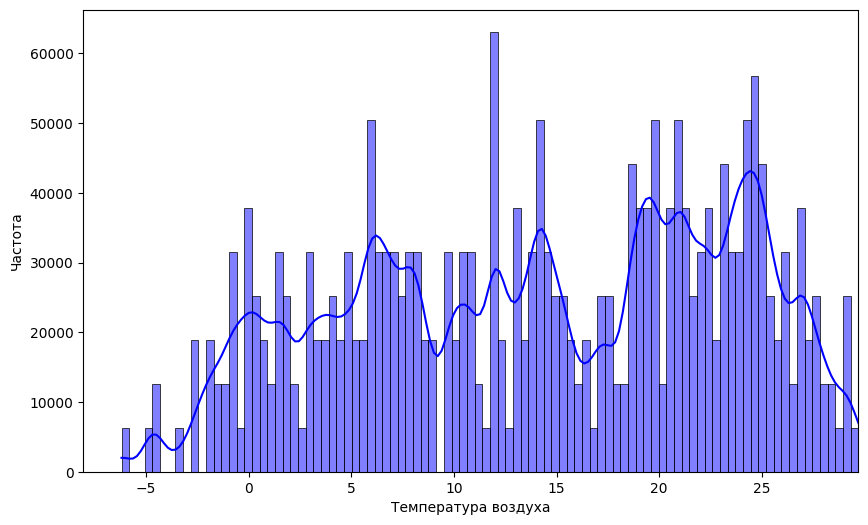

--- precip ---
Описание: Осадки?
Мин: 0.0
Макс: 165.38
Среднее: 3.87
Медиана: 0.0
Ст. отк.: 12.77



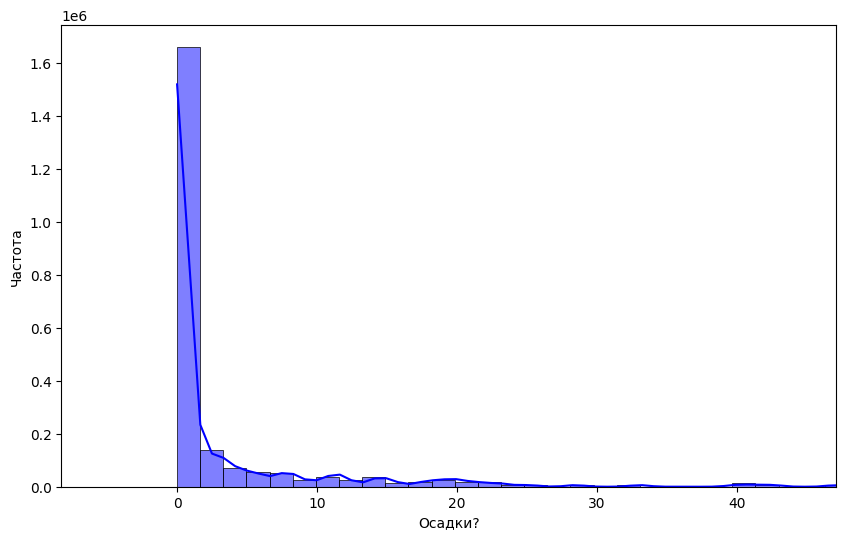

--- precipprob ---
Описание: Вероятность осадков
Мин: 0
Макс: 100
Среднее: 41.23
Медиана: 0.0
Ст. отк.: 49.22



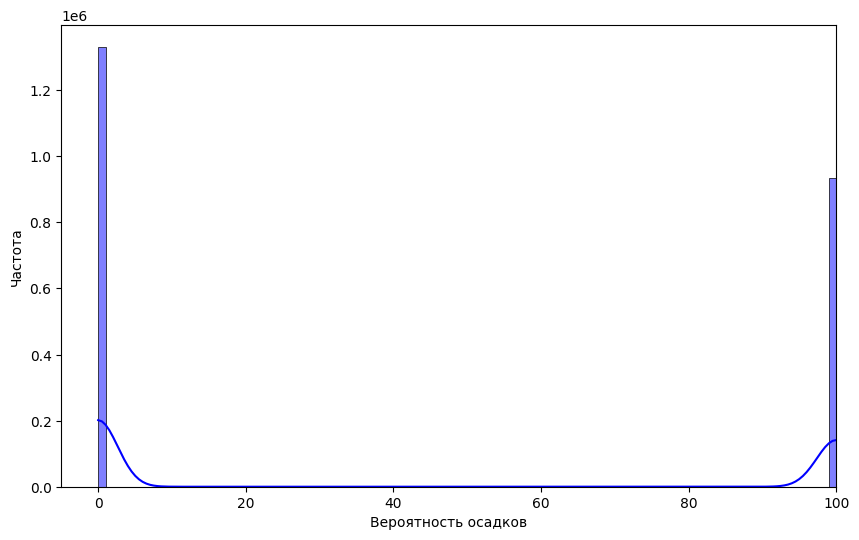

--- windgust ---
Описание: Порывы ветра
Мин: 25.9
Макс: 94.3
Среднее: 44.28
Медиана: 42.5
Ст. отк.: 12.20



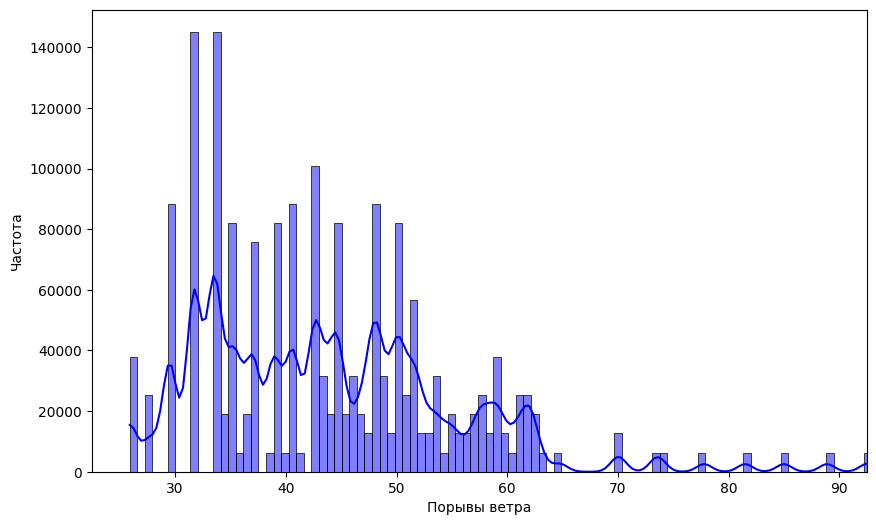

--- windspeed ---
Описание: Скорость ветра
Мин: 8.0
Макс: 50.0
Среднее: 21.23
Медиана: 20.7
Ст. отк.: 7.14



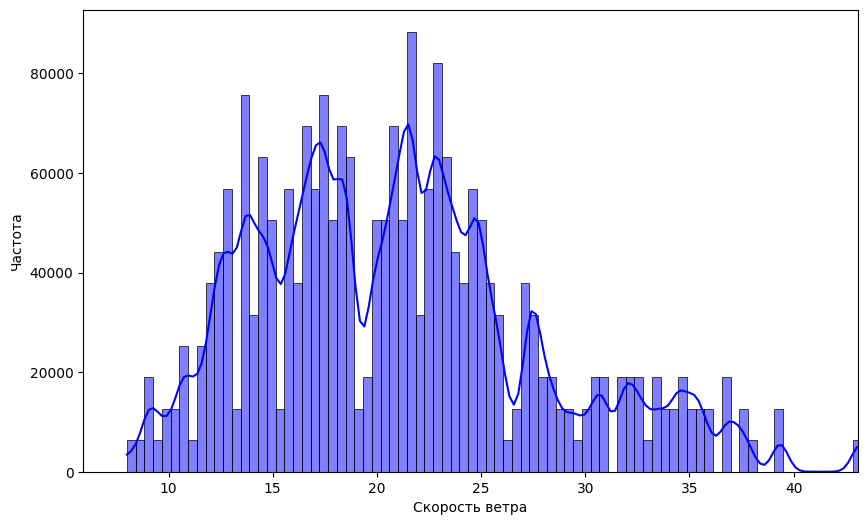

In [13]:
stats = []

for col in base_atributes:
    stats.extend([
        pl.col(col).min().alias(f'{col}_min'),
        pl.col(col).max().alias(f'{col}_max'),
        pl.col(col).mean().alias(f'{col}_mean'),
        pl.col(col).median().alias(f'{col}_median'),
        pl.col(col).std().alias(f'{col}_std')
    ])

results = result_df.select(stats)
for col in base_atributes:
    print(f"--- {col} ---")
    print(f"Описание: {description[col]}")
    print(f"Мин: {results[0, f'{col}_min']}")
    print(f"Макс: {results[0, f'{col}_max']}")
    print(f"Среднее: {results[0, f'{col}_mean']:.2f}")
    print(f"Медиана: {results[0, f'{col}_median']}")
    print(f"Ст. отк.: {results[0, f'{col}_std']:.2f}\n")
    
    plt.figure(figsize=(10, 6))
    # Гистограмма распределения
    sns.histplot(result_df[col], bins=100, kde=True, color='blue')
    
    plt.xlabel(description[col])
    plt.ylabel('Частота')
    # Ограничим X, если есть экстремальные выбросы (например, аэропорты)
    plt.xlim(right=result_df[col].quantile(0.99)) 
    plt.show()

## Распределение Целевой переменной

--- trips_count ---
Описание: Кол-во поездок за час из определенной зоны
Мин: 0
Макс: 2085
Среднее: 76.14
Медиана: 51.0
Ст. отк.: 83.47



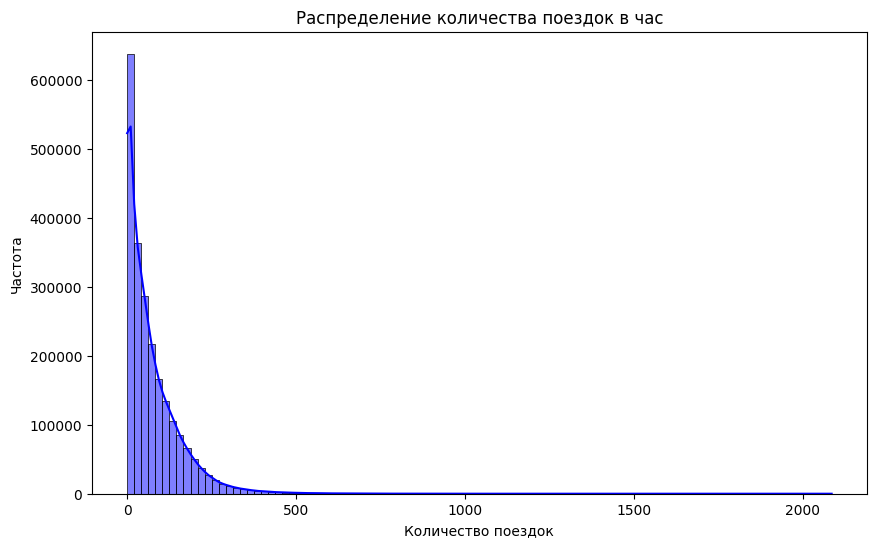

In [14]:
stats = []
stats.extend([
    pl.col(target).min().alias(f'{target}_min'),
    pl.col(target).max().alias(f'{target}_max'),
    pl.col(target).mean().alias(f'{target}_mean'),
    pl.col(target).median().alias(f'{target}_median'),
    pl.col(target).std().alias(f'{target}_std')
])
results = result_df.select(stats)
print(f"--- {target} ---")
print(f"Описание: {description[target]}")
print(f"Мин: {results[0, f'{target}_min']}")
print(f"Макс: {results[0, f'{target}_max']}")
print(f"Среднее: {results[0, f'{target}_mean']:.2f}")
print(f"Медиана: {results[0, f'{target}_median']}")
print(f"Ст. отк.: {results[0, f'{target}_std']:.2f}\n")

plt.figure(figsize=(10, 6))
# Гистограмма распределения
sns.histplot(result_df['trips_count'], bins=100, kde=True, color='blue')

plt.title('Распределение количества поездок в час')
plt.xlabel('Количество поездок')
plt.ylabel('Частота')
plt.show()

## Разделяем датасет на выборку для кросс-валидации и тестовую

In [14]:
# 1. Сортируем (на всякий случай, для временных рядов это критично)
result_df = result_df.sort("hour_bucket")

# 2. Разделяем по датам (например, 2021 год)
train_cv_finish = datetime(2021, 11, 30)
train_cv = result_df.filter(pl.col("hour_bucket") < train_cv_finish)
test  = result_df.filter(pl.col("hour_bucket") >= train_cv_finish)

print(f"Train: {train_cv.shape[0]} строк")
print(f"Test:  {test.shape[0]} строк")

Train: 2064024 строк
Test:  201984 строк


## Масштабируем метеоданные

In [ ]:
# from sklearn.preprocessing import MinMaxScaler
# # 1. Выделяем числовые признаки
# numeric_cols = [
#     'datetime', 'temp', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
#     'snowdepth', 'windgust','windspeed', 'winddir',
#     'sealevelpressure', 'cloudcover', 'visibility', 'uvindex'
# ]
# # 2. Инициализируем MinMaxScaler
# # Он идеально подходит для LSTM
# scaler = MinMaxScaler(feature_range=(0, 1))
# # 3. Применяем (только после разделения на train/test!)
# train_scaled = scaler.fit_transform(X_train[numeric_cols])
# test_scaled = scaler.transform(X_test[numeric_cols])

# Построение моделей

## Алгоритм Random Forest
### Подбор гиперпараметров алгоритма

In [15]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import pandas as pd
import optuna
import numpy as np
import warnings

# 1. Подготовка признаков
features = [col for col in train_cv.columns if col not in [target, "hour_bucket"]]

# 2. ПРЕВРАЩАЕМ В NUMPY СРАЗУ (Чтобы не было имен колонок вообще)
X_np = train_cv.select(features).to_pandas().values
y_np = train_cv.select(target).to_pandas().values.ravel()

# 31 день по 24 часа — хороший размер для валидации
tscv = TimeSeriesSplit(n_splits=3, test_size=24*31)
warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [16]:
def objective(trial):
    param = {
        "boosting_type": "rf",
        "objective": "regression",
        "metric": "rmse",
        "n_estimators": trial.suggest_int("n_estimators", 250, 800),
        "num_leaves": 3876,
        "max_depth": 26,
        "min_child_samples": trial.suggest_int("min_child_samples", 120, 800),
        "subsample": trial.suggest_float("subsample", 0.5, 0.8),
        "subsample_freq": 1,
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 0.9),
        "n_jobs": -1,
        "random_state": 42,
        "verbose": -1
    }
    
    scores = []
    
    # Теперь итерируемся по X_np (массиву), так чище и быстрее
    for i, (train_idx, val_idx) in enumerate(tscv.split(X_np)):
        X_train, X_val = X_np[train_idx], X_np[val_idx]
        y_train, y_val = y_np[train_idx], y_np[val_idx]

        model = lgb.LGBMRegressor(**param)
        
        # Здесь нет имен колонок, LightGBM будет работать только с индексами
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        scores.append(rmse)

        trial.report(rmse, i)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(scores)

# Настройка исследования
study = optuna.create_study(
    direction="minimize", 
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1)
)

# Запуск
study.optimize(objective, n_trials=20)

print(f"Лучшие параметры: {study.best_params}")

[I 2026-04-12 13:21:35,986] A new study created in memory with name: no-name-f7e888fe-b2ce-457f-8e68-8586958c5ff5
[I 2026-04-12 13:43:51,181] Trial 0 finished with value: 30.108431544791443 and parameters: {'n_estimators': 569, 'min_child_samples': 164, 'subsample': 0.7083592942948536, 'feature_fraction': 0.7597824674418262}. Best is trial 0 with value: 30.108431544791443.
[I 2026-04-12 13:54:05,836] Trial 1 finished with value: 31.410837283729183 and parameters: {'n_estimators': 422, 'min_child_samples': 675, 'subsample': 0.5901683021632546, 'feature_fraction': 0.7695324858132656}. Best is trial 0 with value: 30.108431544791443.
[I 2026-04-12 14:04:20,274] Trial 2 finished with value: 32.73389310656605 and parameters: {'n_estimators': 448, 'min_child_samples': 711, 'subsample': 0.6122140307268357, 'feature_fraction': 0.6345571210218166}. Best is trial 0 with value: 30.108431544791443.
[I 2026-04-12 14:20:06,985] Trial 3 finished with value: 30.737249260013712 and parameters: {'n_estim

Лучшие параметры: {'n_estimators': 671, 'min_child_samples': 122, 'subsample': 0.7926776306121933, 'feature_fraction': 0.8688065282212014}


### Отбор признаков с помощью Permutation Importance

In [17]:
import optuna.visualization as vis

vis.plot_param_importances(study)

#vis.plot_parallel_coordinate(study)

### Обучение модели

## Алгоритм XGBoost
### Подбор гиперпараметров алгоритма

### Отбор признаков с помощью Permitation Importance

### Отбор признаков с помощью XGBoost

### Обучение модели

## LSTM

### Подготовка данных для LSTM. Масштабирование метеоданных

### Обучение модели

# Оценка построенных моделей на отложенной выборке